# Debug Embedding Geometry — TEST_ISAB3

Examines checkpoint `experiments/TEST_ISAB3` with PCA + UMAP projections,
peak-count distribution, and quantitative correlation diagnostics.

In [1]:
import os
import sys

os.chdir(os.path.join(os.path.dirname(os.getcwd()) if os.path.basename(os.getcwd()) == "notebooks" else os.getcwd()))
if os.getcwd() not in sys.path:
    sys.path.insert(0, os.getcwd())

print("Working directory:", os.getcwd())

Working directory: /home/wuhao/spectra-learning


In [2]:
# Configuration
CHECKPOINT_DIR = "experiments/TEST_ISAB3/trial_000"
CONFIG_PATH = "configs/gems_a_50_mask.py"
DEVICE = "cuda"  # falls back to CPU if unavailable

RANDOM_SEED = 42
UMAP_MAX_SAMPLES = 50_000
UMAP_NEIGHBORS = 30
UMAP_MIN_DIST = 0.3

In [3]:
import logging
import warnings
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
from sklearn.decomposition import PCA
from sklearn.neighbors import NearestNeighbors
from scipy.sparse.csgraph import connected_components
from tqdm.auto import tqdm
import umap

from utils.training import load_config, build_model_from_config, load_pretrained_weights, latest_ckpt_path
from input_pipeline import TfLightningDataModule
from utils.probing import iter_massspec_probe

warnings.filterwarnings("ignore")
logging.basicConfig(level=logging.INFO)
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)

/home/wuhao/spectra-learning/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


2026-02-19 06:16:54.564333: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-02-19 06:16:54.595372: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


2026-02-19 06:16:55.519634: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


## 1. Load Config, DataModule, and Frozen Backbone

In [4]:
config = load_config(CONFIG_PATH)
datamodule = TfLightningDataModule(config, seed=int(config.seed))

config.num_peaks = datamodule.info["num_peaks"]
config.fingerprint_bits = int(datamodule.info["fingerprint_bits"])

backbone = build_model_from_config(config)
ckpt_path = latest_ckpt_path(Path(CHECKPOINT_DIR))
print(f"Loading checkpoint: {ckpt_path}")
load_pretrained_weights(backbone, ckpt_path)

device = torch.device(DEVICE if torch.cuda.is_available() else "cpu")
backbone = backbone.to(device)
backbone.eval()
for p in backbone.parameters():
    p.requires_grad = False

print(f"Model on {device}, params={sum(p.numel() for p in backbone.parameters()):,}")
print(f"pooling_type={config.pooling_type}, num_peaks={config.num_peaks}")
print("Embedding source: backbone.pool(backbone.encoder(...)) [pre-projector]")
print(f"train_size={datamodule.info['massspec_train_size']:,}")

INFO:input_pipeline:Found existing TFRecords at /home/wuhao/spectra-learning/data/gems_peaklist_tfrecord


Loading checkpoint: experiments/TEST_ISAB3/trial_000/checkpoints/step-00100000.pt


Model on cuda, params=19,842,432
pooling_type=pma, num_peaks=60
Embedding source: backbone.pool(backbone.encoder(...)) [pre-projector]
train_size=194,119


## 2. Extract Pooled Embeddings From Full Train Split

In [5]:
embed_list = []
labels = {
    "adduct": [],
    "instrument": [],
    "precursor_mz": [],
    "n_valid_peaks": [],
}

probe_peak_ordering = str(config.peak_ordering)
print("Extracting backbone.pool(...) embeddings from massspec_train (before projector)...")

with torch.no_grad():
    for batch in tqdm(iter_massspec_probe(
        datamodule,
        "massspec_train",
        seed=RANDOM_SEED,
        peak_ordering=probe_peak_ordering,
        drop_remainder=False,
    )):
        batch_dev = {k: v.to(device) for k, v in batch.items()}
        embeddings = backbone.encoder(
            batch_dev["peak_mz"],
            batch_dev["peak_intensity"],
            valid_mask=batch_dev["peak_valid_mask"],
            precursor_mz=batch_dev.get("precursor_mz"),
        )
        pooled = backbone.pool(embeddings, batch_dev["peak_valid_mask"])

        embed_list.append(pooled.cpu().float())
        labels["adduct"].append(batch["adduct_id"].to(torch.long))
        labels["instrument"].append(batch["instrument_type_id"].to(torch.long))
        labels["precursor_mz"].append(batch["precursor_mz"].to(torch.float32))
        labels["n_valid_peaks"].append(batch["peak_valid_mask"].sum(dim=1).to(torch.long))

all_embeds = torch.cat(embed_list, dim=0).numpy()
all_labels = {k: torch.cat(v).numpy() for k, v in labels.items()}

print(f"Embeddings shape: {all_embeds.shape} ({all_embeds.nbytes / 1e6:.1f} MB)")
print(f"n_valid_peaks range: {all_labels['n_valid_peaks'].min()}..{all_labels['n_valid_peaks'].max()}")

Extracting backbone.pool(...) embeddings from massspec_train (before projector)...


0it [00:00, ?it/s]

2026-02-19 06:16:58.465043: I tensorflow/core/kernels/data/tf_record_dataset_op.cc:387] The default buffer size is 262144, which is overridden by the user specified `buffer_size` of 250000


1it [00:03,  3.30s/it]

2it [00:03,  1.44s/it]

...

378it [00:56,  4.16it/s]

379it [00:56,  4.76it/s]

380it [00:56,  3.70it/s]

2026-02-19 06:17:54.946652: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
380it [00:56,  6.70it/s]

Embeddings shape: (194119, 256) (198.8 MB)
n_valid_peaks range: 0..60


## 3. Peak-Count Distribution (Potential Geometry Driver)

Top peak-count frequencies:
  peaks=60  count= 25492  (13.13%)
  peaks= 2  count=  8473  ( 4.36%)
  peaks= 3  count=  7730  ( 3.98%)
  peaks= 4  count=  7208  ( 3.71%)
  peaks= 5  count=  7002  ( 3.61%)
  peaks= 1  count=  6775  ( 3.49%)
  peaks= 6  count=  6747  ( 3.48%)
  peaks= 7  count=  6346  ( 3.27%)
  peaks= 8  count=  6283  ( 3.24%)
  peaks= 9  count=  5612  ( 2.89%)
  peaks=10  count=  5434  ( 2.80%)
  peaks=11  count=  5075  ( 2.61%)
  peaks=12  count=  4932  ( 2.54%)
  peaks=13  count=  4739  ( 2.44%)
  peaks=14  count=  4656  ( 2.40%)

<=5 peaks: 37292 (19.21%)
==60 peaks: 25492 (13.13%)


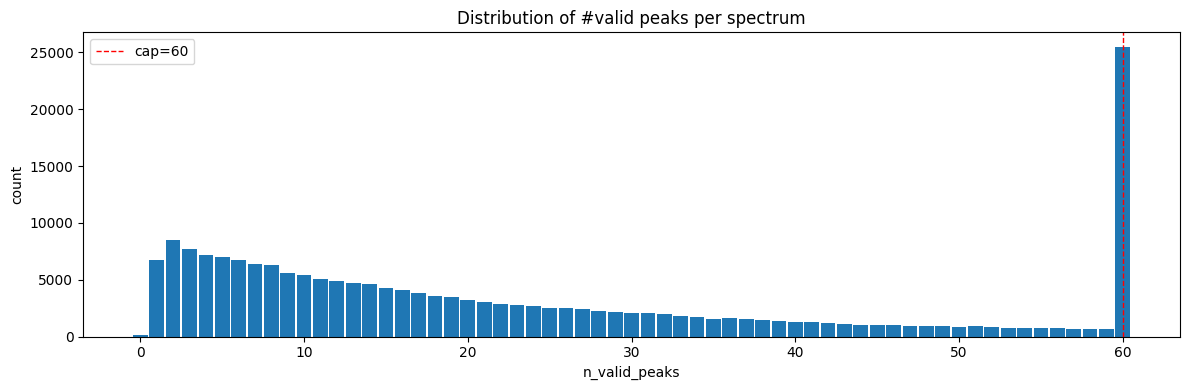

In [6]:
peak_counts = all_labels["n_valid_peaks"]
vals, counts = np.unique(peak_counts, return_counts=True)
order = np.argsort(-counts)

print("Top peak-count frequencies:")
for i in order[:15]:
    print(f"  peaks={int(vals[i]):2d}  count={int(counts[i]):6d}  ({counts[i] / peak_counts.size * 100:5.2f}%)")

print(f"\n<=5 peaks: {(peak_counts <= 5).sum()} ({(peak_counts <= 5).mean() * 100:.2f}%)")
print(f"==60 peaks: {(peak_counts == 60).sum()} ({(peak_counts == 60).mean() * 100:.2f}%)")

fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(vals, counts, width=0.9, edgecolor="none")
ax.set_title("Distribution of #valid peaks per spectrum")
ax.set_xlabel("n_valid_peaks")
ax.set_ylabel("count")
ax.axvline(60, color="red", linestyle="--", linewidth=1, label="cap=60")
ax.legend()
plt.tight_layout()
plt.show()

## 4. PCA: Variance and Annotated 2D Projection

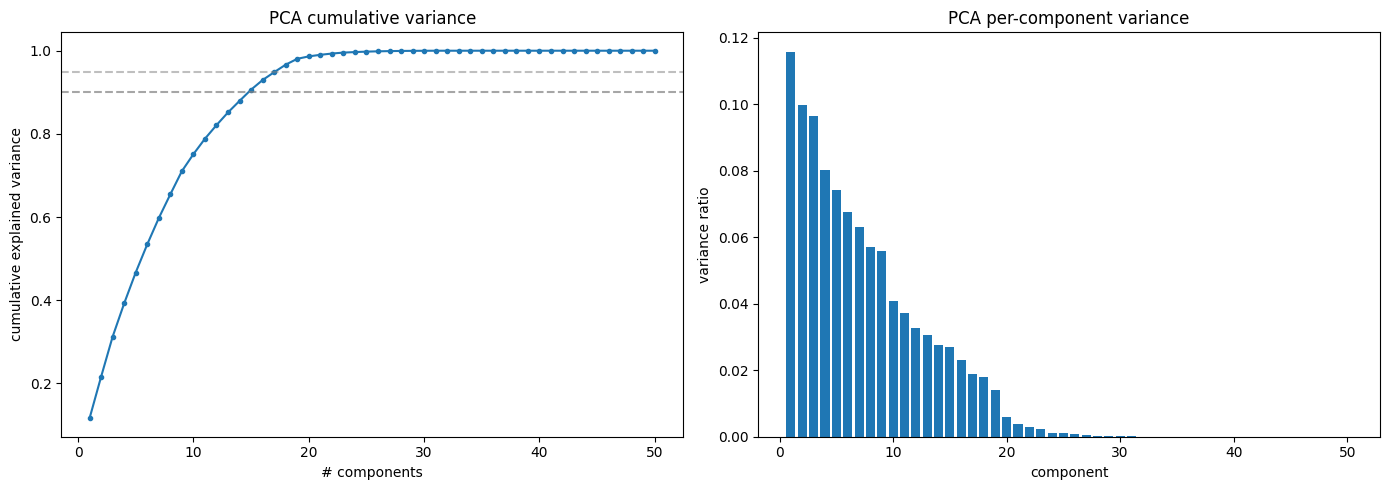

Components for 90% variance: 15
Components for 95% variance: 18
Effective dimensionality (participation ratio): 14.79


In [7]:
pca_full = PCA(n_components=min(50, all_embeds.shape[1]))
pca_full.fit(all_embeds)

cumvar = np.cumsum(pca_full.explained_variance_ratio_)
n90 = int(np.searchsorted(cumvar, 0.90)) + 1
n95 = int(np.searchsorted(cumvar, 0.95)) + 1
pr = (pca_full.explained_variance_ratio_.sum() ** 2) / (pca_full.explained_variance_ratio_ ** 2).sum()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(np.arange(1, len(cumvar) + 1), cumvar, marker="o", markersize=3)
axes[0].axhline(0.90, linestyle="--", color="gray", alpha=0.7)
axes[0].axhline(0.95, linestyle="--", color="gray", alpha=0.5)
axes[0].set_title("PCA cumulative variance")
axes[0].set_xlabel("# components")
axes[0].set_ylabel("cumulative explained variance")

axes[1].bar(np.arange(1, len(pca_full.explained_variance_ratio_) + 1), pca_full.explained_variance_ratio_, edgecolor="none")
axes[1].set_title("PCA per-component variance")
axes[1].set_xlabel("component")
axes[1].set_ylabel("variance ratio")

plt.tight_layout()
plt.show()

print(f"Components for 90% variance: {n90}")
print(f"Components for 95% variance: {n95}")
print(f"Effective dimensionality (participation ratio): {pr:.2f}")

coords_pca = PCA(n_components=2).fit_transform(all_embeds)

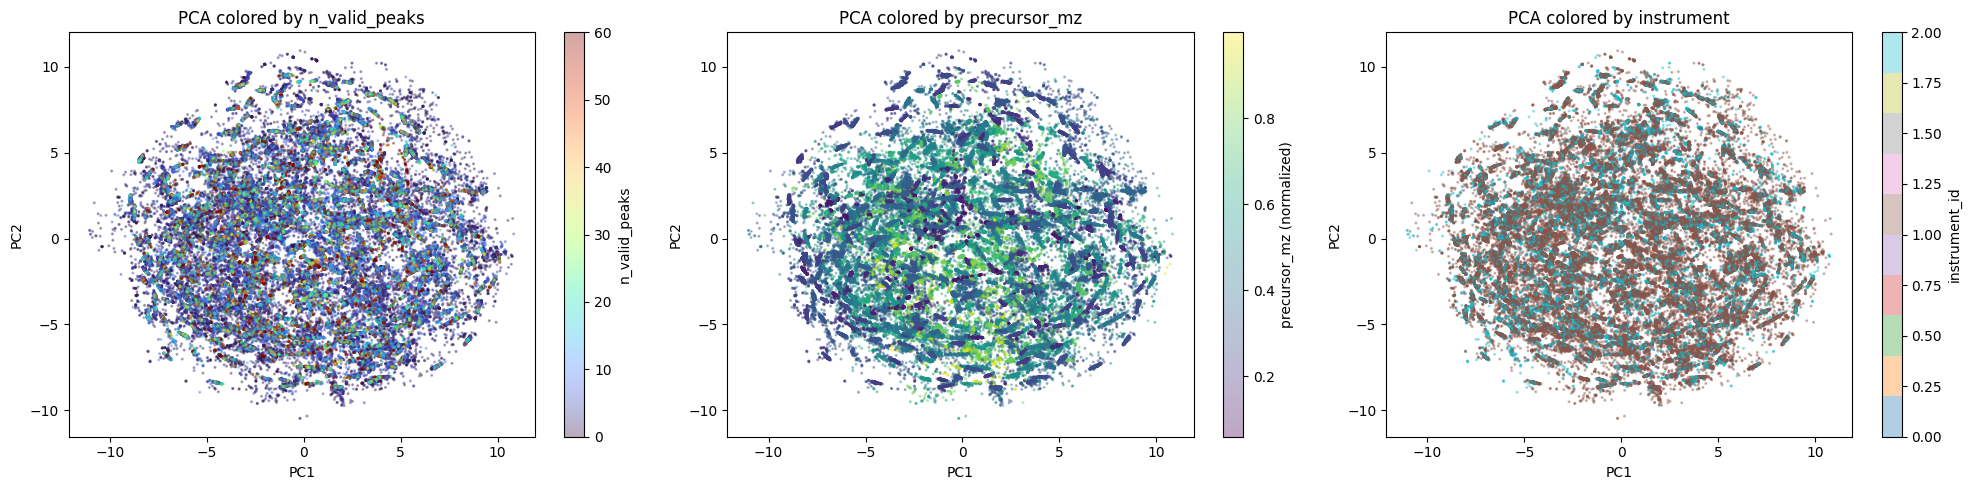

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

sc0 = axes[0].scatter(coords_pca[:, 0], coords_pca[:, 1], c=all_labels["n_valid_peaks"], cmap="turbo", s=1.5, alpha=0.35, rasterized=True)
axes[0].set_title("PCA colored by n_valid_peaks")
plt.colorbar(sc0, ax=axes[0], label="n_valid_peaks")

sc1 = axes[1].scatter(coords_pca[:, 0], coords_pca[:, 1], c=all_labels["precursor_mz"], cmap="viridis", s=1.5, alpha=0.35, rasterized=True)
axes[1].set_title("PCA colored by precursor_mz")
plt.colorbar(sc1, ax=axes[1], label="precursor_mz (normalized)")

sc2 = axes[2].scatter(coords_pca[:, 0], coords_pca[:, 1], c=all_labels["instrument"], cmap="tab10", s=1.5, alpha=0.35, rasterized=True)
axes[2].set_title("PCA colored by instrument")
plt.colorbar(sc2, ax=axes[2], label="instrument_id")

for ax in axes:
    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")

plt.tight_layout()
plt.show()

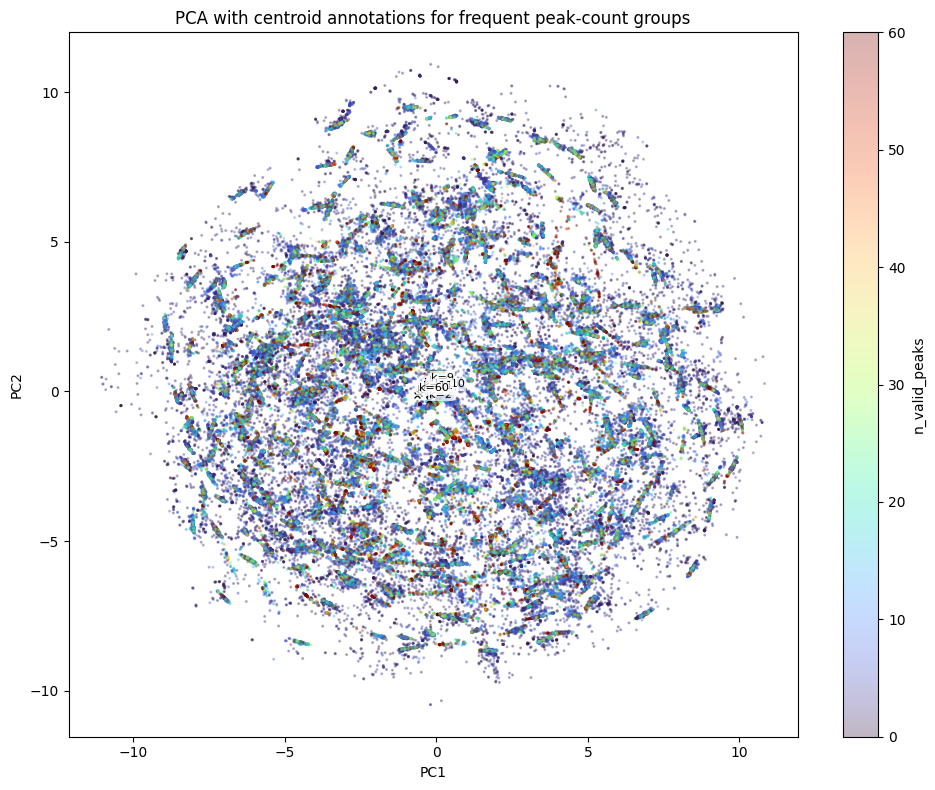

Annotated peak-count groups: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 60]


In [9]:
def annotate_peak_count_centroids(ax, coords, peak_counts, chosen_counts):
    for c in chosen_counts:
        mask = peak_counts == c
        x = np.median(coords[mask, 0])
        y = np.median(coords[mask, 1])
        ax.scatter([x], [y], c="black", s=18, marker="x", linewidths=0.9)
        ax.text(
            x,
            y,
            f"k={int(c)}",
            fontsize=8,
            ha="left",
            va="bottom",
            color="black",
            bbox=dict(facecolor="white", alpha=0.7, edgecolor="none", pad=1.0),
        )

vals, counts = np.unique(all_labels["n_valid_peaks"], return_counts=True)
chosen_counts = vals[np.argsort(-counts)[:12]]
chosen_counts = np.sort(chosen_counts)

fig, ax = plt.subplots(figsize=(10, 8))
sc = ax.scatter(
    coords_pca[:, 0],
    coords_pca[:, 1],
    c=all_labels["n_valid_peaks"],
    cmap="turbo",
    s=1.5,
    alpha=0.30,
    rasterized=True,
)
annotate_peak_count_centroids(ax, coords_pca, all_labels["n_valid_peaks"], chosen_counts)

ax.set_title("PCA with centroid annotations for frequent peak-count groups")
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
plt.colorbar(sc, ax=ax, label="n_valid_peaks")
plt.tight_layout()
plt.show()

print("Annotated peak-count groups:", chosen_counts.tolist())

## 5. UMAP: Projection and Annotations

In [10]:
n_total = all_embeds.shape[0]
if n_total > UMAP_MAX_SAMPLES:
    rng = np.random.RandomState(RANDOM_SEED)
    sample_idx = rng.choice(n_total, size=UMAP_MAX_SAMPLES, replace=False)
else:
    sample_idx = np.arange(n_total)

umap_embeds = all_embeds[sample_idx]
umap_labels = {k: v[sample_idx] for k, v in all_labels.items()}

print(f"UMAP input shape: {umap_embeds.shape}")
print(f"UMAP params: n_neighbors={UMAP_NEIGHBORS}, min_dist={UMAP_MIN_DIST}, metric=cosine")

reducer = umap.UMAP(
    n_components=2,
    n_neighbors=UMAP_NEIGHBORS,
    min_dist=UMAP_MIN_DIST,
    metric="cosine",
    random_state=RANDOM_SEED,
)
coords_umap = reducer.fit_transform(umap_embeds)
print(f"coords_umap shape: {coords_umap.shape}")

UMAP input shape: (50000, 256)
UMAP params: n_neighbors=30, min_dist=0.3, metric=cosine


coords_umap shape: (50000, 2)


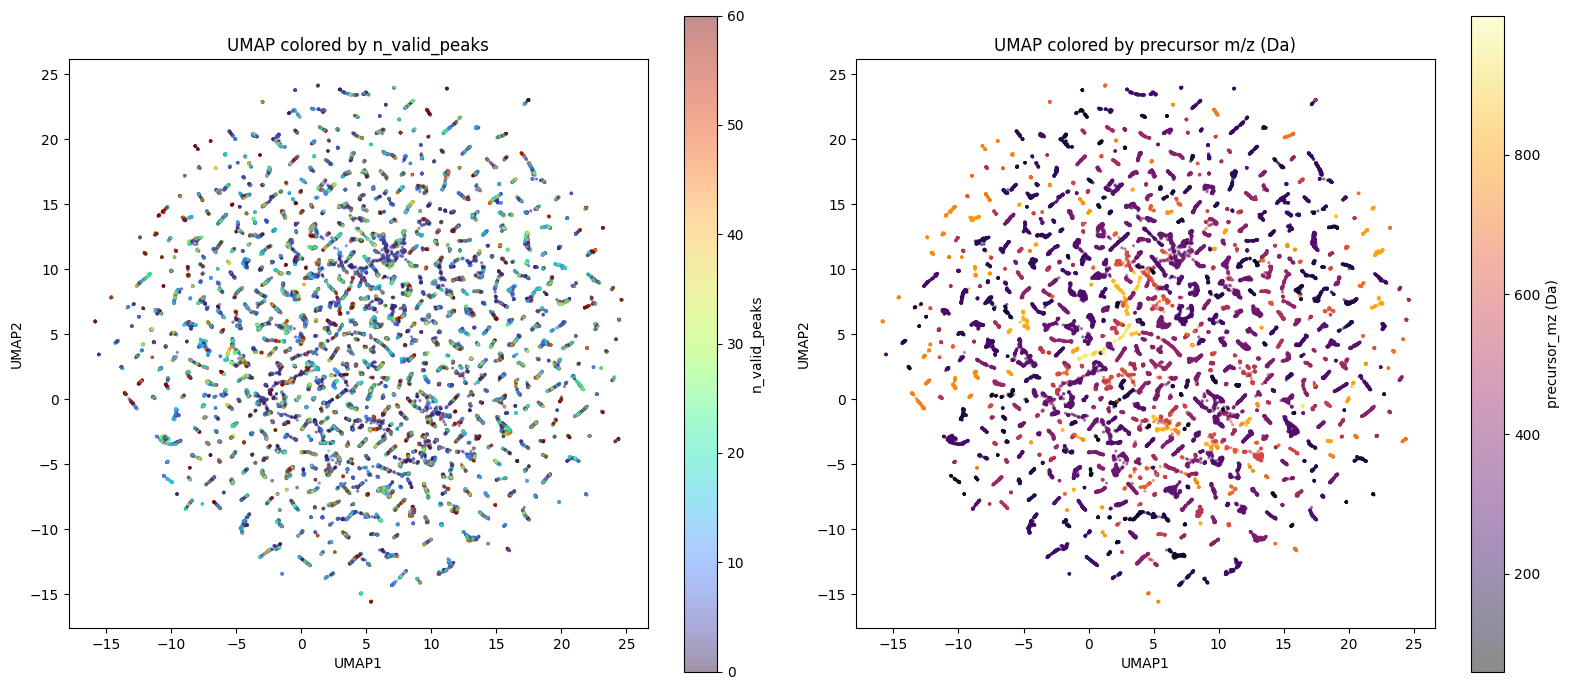

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

sc0 = axes[0].scatter(
    coords_umap[:, 0],
    coords_umap[:, 1],
    c=umap_labels["n_valid_peaks"],
    cmap="turbo",
    s=2.0,
    alpha=0.45,
    rasterized=True,
)
axes[0].set_title("UMAP colored by n_valid_peaks")
plt.colorbar(sc0, ax=axes[0], label="n_valid_peaks")

sc1 = axes[1].scatter(
    coords_umap[:, 0],
    coords_umap[:, 1],
    c=umap_labels["precursor_mz"] * float(config.max_precursor_mz),
    cmap="inferno",
    s=2.0,
    alpha=0.45,
    rasterized=True,
)
axes[1].set_title("UMAP colored by precursor m/z (Da)")
plt.colorbar(sc1, ax=axes[1], label="precursor_mz (Da)")

for ax in axes:
    ax.set_xlabel("UMAP1")
    ax.set_ylabel("UMAP2")
    ax.set_aspect("equal")

plt.tight_layout()
plt.show()

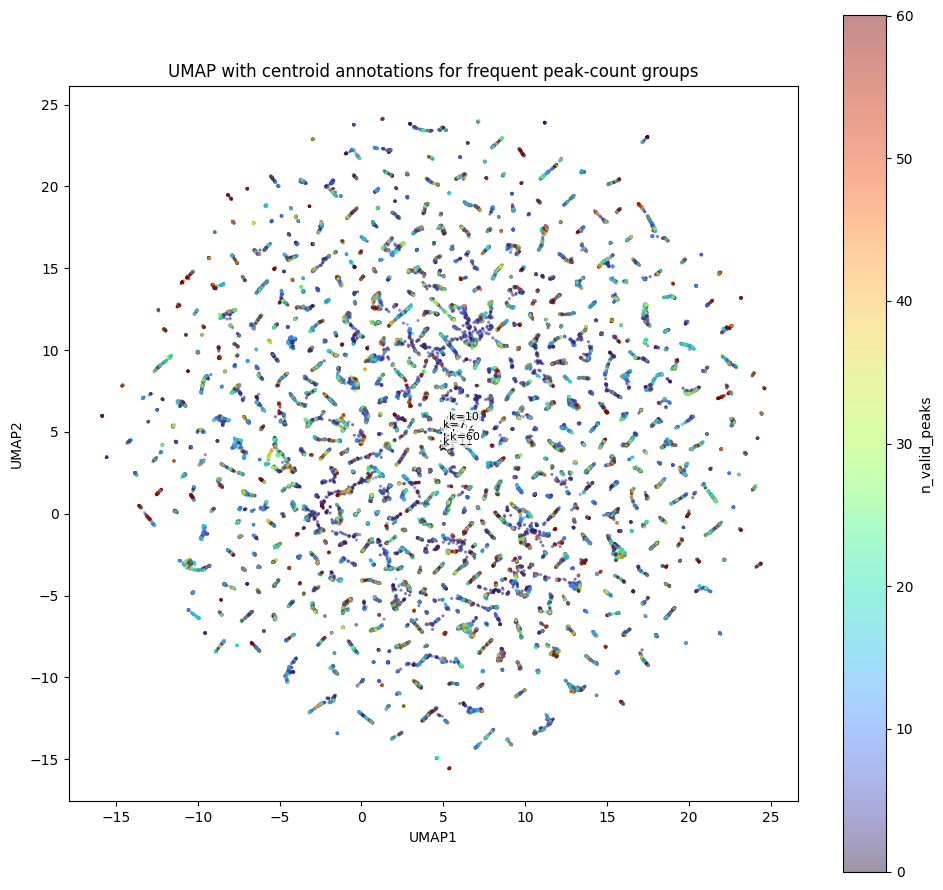

Annotated peak-count groups (UMAP sample): [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 60]


In [12]:
vals_u, counts_u = np.unique(umap_labels["n_valid_peaks"], return_counts=True)
chosen_counts_u = vals_u[np.argsort(-counts_u)[:12]]
chosen_counts_u = np.sort(chosen_counts_u)

fig, ax = plt.subplots(figsize=(10, 9))
sc = ax.scatter(
    coords_umap[:, 0],
    coords_umap[:, 1],
    c=umap_labels["n_valid_peaks"],
    cmap="turbo",
    s=2.0,
    alpha=0.45,
    rasterized=True,
)
annotate_peak_count_centroids(ax, coords_umap, umap_labels["n_valid_peaks"], chosen_counts_u)

ax.set_title("UMAP with centroid annotations for frequent peak-count groups")
ax.set_xlabel("UMAP1")
ax.set_ylabel("UMAP2")
ax.set_aspect("equal")
plt.colorbar(sc, ax=ax, label="n_valid_peaks")
plt.tight_layout()
plt.show()

print("Annotated peak-count groups (UMAP sample):", chosen_counts_u.tolist())

## 6. Quantitative Diagnostics

In [13]:
def corr(a, b):
    return float(np.corrcoef(a, b)[0, 1])

print("PCA axis correlations")
print(f"  corr(PC1, n_valid_peaks) = {corr(coords_pca[:, 0], all_labels['n_valid_peaks']): .4f}")
print(f"  corr(PC2, n_valid_peaks) = {corr(coords_pca[:, 1], all_labels['n_valid_peaks']): .4f}")
print(f"  corr(PC1, precursor_mz)  = {corr(coords_pca[:, 0], all_labels['precursor_mz']): .4f}")
print(f"  corr(PC2, precursor_mz)  = {corr(coords_pca[:, 1], all_labels['precursor_mz']): .4f}")

print("\nUMAP axis correlations (sampled set)")
print(f"  corr(UMAP1, n_valid_peaks) = {corr(coords_umap[:, 0], umap_labels['n_valid_peaks']): .4f}")
print(f"  corr(UMAP2, n_valid_peaks) = {corr(coords_umap[:, 1], umap_labels['n_valid_peaks']): .4f}")
print(f"  corr(UMAP1, precursor_mz)  = {corr(coords_umap[:, 0], umap_labels['precursor_mz']): .4f}")
print(f"  corr(UMAP2, precursor_mz)  = {corr(coords_umap[:, 1], umap_labels['precursor_mz']): .4f}")

PCA axis correlations
  corr(PC1, n_valid_peaks) = -0.0139
  corr(PC2, n_valid_peaks) = -0.0005
  corr(PC1, precursor_mz)  =  0.0027
  corr(PC2, precursor_mz)  = -0.0479

UMAP axis correlations (sampled set)
  corr(UMAP1, n_valid_peaks) =  0.0060
  corr(UMAP2, n_valid_peaks) = -0.0065
  corr(UMAP1, precursor_mz)  =  0.0053
  corr(UMAP2, precursor_mz)  = -0.0188


In [14]:
# Connectivity in original high-D space (UMAP sample)
knn = NearestNeighbors(n_neighbors=UMAP_NEIGHBORS, metric="cosine", algorithm="brute")
knn.fit(umap_embeds)
graph_hd = knn.kneighbors_graph(umap_embeds, mode="connectivity")
graph_hd = graph_hd.maximum(graph_hd.T)
num_comp_hd, _ = connected_components(graph_hd, directed=False)

print(f"High-D kNN graph components: {num_comp_hd}")

# Connectivity in 2D UMAP space (radius graph)
knn2 = NearestNeighbors(n_neighbors=6)
knn2.fit(coords_umap)
dists, _ = knn2.kneighbors(coords_umap)
radius = float(np.quantile(dists[:, 1], 0.95) * 2.5)

graph_2d = NearestNeighbors(radius=radius).fit(coords_umap).radius_neighbors_graph(coords_umap, mode="connectivity")
graph_2d = graph_2d.maximum(graph_2d.T)
num_comp_2d, comp_2d = connected_components(graph_2d, directed=False)

vals_c, counts_c = np.unique(comp_2d, return_counts=True)
order_c = np.argsort(-counts_c)

print(f"2D radius-graph components: {num_comp_2d} (radius={radius:.4f})")
print("Top component sizes:", counts_c[order_c][:12].tolist())
print("\nLargest component summaries (n_valid_peaks, precursor_mz):")
for comp_id in vals_c[order_c][:10]:
    mask = comp_2d == comp_id
    size = int(mask.sum())
    print(
        f"  comp={int(comp_id):3d} size={size:5d}  "
        f"peaks_mean={umap_labels['n_valid_peaks'][mask].mean():6.2f} "
        f"peaks_range=({umap_labels['n_valid_peaks'][mask].min():2d},{umap_labels['n_valid_peaks'][mask].max():2d}) "
        f"prec_mz_mean={umap_labels['precursor_mz'][mask].mean():.3f}"
    )

High-D kNN graph components: 35


2D radius-graph components: 1484 (radius=0.1008)
Top component sizes: [297, 239, 229, 226, 225, 220, 206, 206, 205, 205, 201, 196]

Largest component summaries (n_valid_peaks, precursor_mz):
  comp= 53 size=  297  peaks_mean= 25.45 peaks_range=( 1,60) prec_mz_mean=0.266
  comp= 19 size=  239  peaks_mean= 22.71 peaks_range=( 1,60) prec_mz_mean=0.287
  comp=224 size=  229  peaks_mean= 21.75 peaks_range=( 1,60) prec_mz_mean=0.290
  comp=251 size=  226  peaks_mean= 19.55 peaks_range=( 1,60) prec_mz_mean=0.268
  comp=164 size=  225  peaks_mean= 29.43 peaks_range=( 1,60) prec_mz_mean=0.355
  comp=242 size=  220  peaks_mean= 26.36 peaks_range=( 1,60) prec_mz_mean=0.359
  comp=134 size=  206  peaks_mean= 31.08 peaks_range=( 2,60) prec_mz_mean=0.313
  comp=173 size=  206  peaks_mean= 22.86 peaks_range=( 1,60) prec_mz_mean=0.352
  comp= 86 size=  205  peaks_mean= 27.53 peaks_range=( 1,60) prec_mz_mean=0.370
  comp= 55 size=  205  peaks_mean= 25.45 peaks_range=( 1,60) prec_mz_mean=0.271


## 8. Representation Quality Metrics

### 8a. Cosine Similarity Distribution & Uniformity

Checks whether embeddings are well-spread on the hypersphere or collapsing.
- **Uniformity** (Wang & Isola, 2020): measures how uniformly distributed embeddings are. More negative = more uniform = better.
- **Cosine similarity distribution**: should be roughly centered near 0 for well-spread representations; peaked at 1.0 indicates collapse.

Cosine similarity statistics (499,996 random pairs):
  mean = 0.0074
  std  = 0.2590
  min  = -0.8064
  max  = 1.0000
  median = -0.0052

Uniformity (log avg exp(-2*||zi-zj||^2)): -3.3168
  (more negative = more uniform, -inf = perfectly uniform)


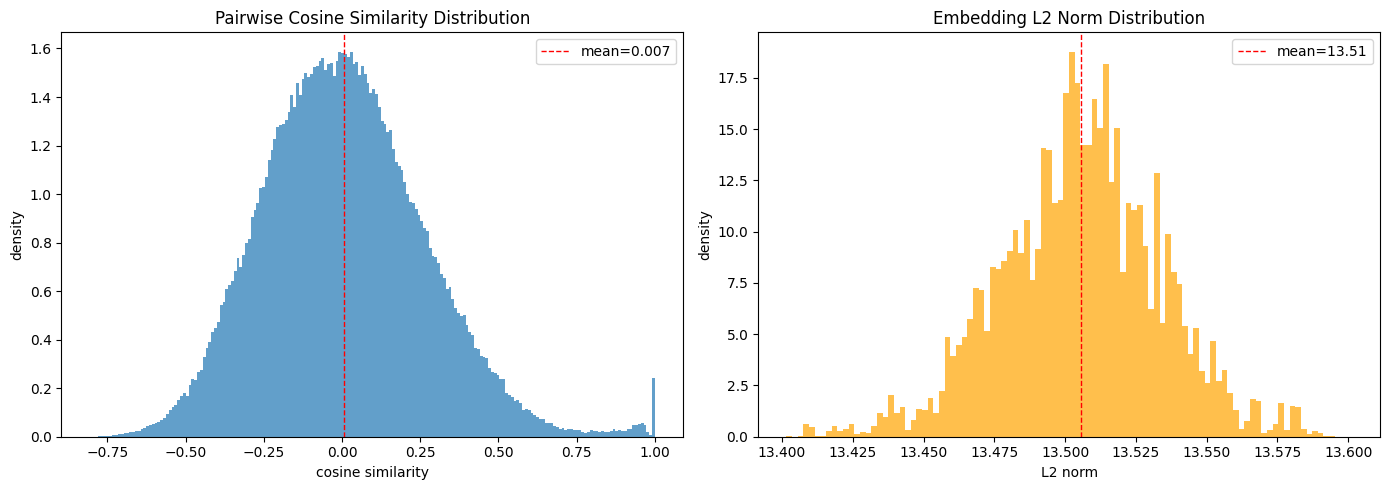


L2 norm: mean=13.505, std=0.028, min=13.402, max=13.601


In [15]:
from sklearn.preprocessing import normalize as l2_normalize

# L2-normalize embeddings for cosine analysis
embeds_normed = l2_normalize(all_embeds, axis=1)

# Sample pairwise cosine similarities (full matrix is too large)
rng_cs = np.random.RandomState(RANDOM_SEED)
n_pairs = 500_000
idx_a = rng_cs.randint(0, len(embeds_normed), size=n_pairs)
idx_b = rng_cs.randint(0, len(embeds_normed), size=n_pairs)
# Exclude self-pairs
mask_diff = idx_a != idx_b
idx_a, idx_b = idx_a[mask_diff], idx_b[mask_diff]
cos_sims = (embeds_normed[idx_a] * embeds_normed[idx_b]).sum(axis=1)

# Uniformity metric: E[exp(-2 * ||z_i - z_j||^2)] for L2-normalized embeddings
# ||z_i - z_j||^2 = 2 - 2*cos(z_i, z_j) for unit vectors
sq_dists = 2.0 - 2.0 * cos_sims
uniformity = float(np.log(np.exp(-2.0 * sq_dists).mean()))

print(f"Cosine similarity statistics ({len(cos_sims):,} random pairs):")
print(f"  mean = {cos_sims.mean():.4f}")
print(f"  std  = {cos_sims.std():.4f}")
print(f"  min  = {cos_sims.min():.4f}")
print(f"  max  = {cos_sims.max():.4f}")
print(f"  median = {np.median(cos_sims):.4f}")
print(f"\nUniformity (log avg exp(-2*||zi-zj||^2)): {uniformity:.4f}")
print("  (more negative = more uniform, -inf = perfectly uniform)")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(cos_sims, bins=200, density=True, alpha=0.7, edgecolor="none")
axes[0].axvline(cos_sims.mean(), color="red", linestyle="--", linewidth=1, label=f"mean={cos_sims.mean():.3f}")
axes[0].set_title("Pairwise Cosine Similarity Distribution")
axes[0].set_xlabel("cosine similarity")
axes[0].set_ylabel("density")
axes[0].legend()

# Also show L2 norm distribution (pre-normalization)
norms = np.linalg.norm(all_embeds, axis=1)
axes[1].hist(norms, bins=100, density=True, alpha=0.7, edgecolor="none", color="orange")
axes[1].axvline(norms.mean(), color="red", linestyle="--", linewidth=1, label=f"mean={norms.mean():.2f}")
axes[1].set_title("Embedding L2 Norm Distribution")
axes[1].set_xlabel("L2 norm")
axes[1].set_ylabel("density")
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"\nL2 norm: mean={norms.mean():.3f}, std={norms.std():.3f}, min={norms.min():.3f}, max={norms.max():.3f}")

### 8b. Linear Probe Accuracy (Logistic Regression)

Quick test of how much task-relevant information is linearly accessible in the embeddings.
Trains a logistic regression on frozen embeddings for adduct and instrument classification.

In [16]:
from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.model_selection import StratifiedKFold, cross_val_score, KFold
from sklearn.metrics import balanced_accuracy_score, r2_score

# Adduct classification (linear probe)
print("=== Linear Probe: Adduct Classification ===")
adduct_labels = all_labels["adduct"]
unique_adducts, adduct_counts = np.unique(adduct_labels, return_counts=True)
print(f"  #classes: {len(unique_adducts)}, class sizes: {sorted(adduct_counts.tolist(), reverse=True)[:10]}...")

clf_adduct = LogisticRegression(max_iter=1000, C=1.0, solver="lbfgs", n_jobs=-1)
cv_adduct = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)
scores_adduct = cross_val_score(clf_adduct, all_embeds, adduct_labels, cv=cv_adduct, scoring="balanced_accuracy", n_jobs=-1)
print(f"  Balanced accuracy (5-fold CV): {scores_adduct.mean():.4f} +/- {scores_adduct.std():.4f}")

# Instrument classification (linear probe)
print("\n=== Linear Probe: Instrument Classification ===")
instr_labels = all_labels["instrument"]
unique_instr, instr_counts = np.unique(instr_labels, return_counts=True)
print(f"  #classes: {len(unique_instr)}, class sizes: {sorted(instr_counts.tolist(), reverse=True)[:10]}...")

clf_instr = LogisticRegression(max_iter=1000, C=1.0, solver="lbfgs", n_jobs=-1)
cv_instr = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)
scores_instr = cross_val_score(clf_instr, all_embeds, instr_labels, cv=cv_instr, scoring="balanced_accuracy", n_jobs=-1)
print(f"  Balanced accuracy (5-fold CV): {scores_instr.mean():.4f} +/- {scores_instr.std():.4f}")

# Precursor m/z regression (Ridge)
print("\n=== Linear Probe: Precursor m/z Regression ===")
ridge = Ridge(alpha=1.0)
cv_reg = KFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)
scores_mz = cross_val_score(ridge, all_embeds, all_labels["precursor_mz"], cv=cv_reg, scoring="r2", n_jobs=-1)
print(f"  R^2 (5-fold CV): {scores_mz.mean():.4f} +/- {scores_mz.std():.4f}")

print("\n--- Summary ---")
print(f"  Adduct balanced acc:    {scores_adduct.mean():.4f}")
print(f"  Instrument balanced acc: {scores_instr.mean():.4f}")
print(f"  Precursor m/z R^2:      {scores_mz.mean():.4f}")

=== Linear Probe: Adduct Classification ===
  #classes: 2, class sizes: [166479, 27640]...


  Balanced accuracy (5-fold CV): 0.5009 +/- 0.0002

=== Linear Probe: Instrument Classification ===
  #classes: 3, class sizes: [140896, 48895, 4328]...


  Balanced accuracy (5-fold CV): 0.3333 +/- 0.0000

=== Linear Probe: Precursor m/z Regression ===


  R^2 (5-fold CV): 0.5784 +/- 0.0047

--- Summary ---
  Adduct balanced acc:    0.5009
  Instrument balanced acc: 0.3333
  Precursor m/z R^2:      0.5784


### 8c. kNN Label Purity

For each embedding, check whether its k nearest neighbors share the same label.
High purity = representations cluster semantically similar spectra together.

In [17]:
# kNN label purity on UMAP subsample (for speed)
K_VALUES = [5, 10, 20, 50]

knn_full = NearestNeighbors(n_neighbors=max(K_VALUES) + 1, metric="cosine", algorithm="brute", n_jobs=-1)
knn_full.fit(umap_embeds)
_, knn_indices = knn_full.kneighbors(umap_embeds)
# Exclude self (index 0)
knn_indices = knn_indices[:, 1:]

print("kNN Label Purity (fraction of k-NN sharing same label)")
print(f"  Sample size: {len(umap_embeds):,}\n")

for label_name in ["adduct", "instrument"]:
    lab = umap_labels[label_name]
    print(f"  {label_name}:")
    for k in K_VALUES:
        neighbor_labels = lab[knn_indices[:, :k]]
        matches = (neighbor_labels == lab[:, None]).mean(axis=1)
        purity = float(matches.mean())
        # Random baseline: probability of same label by chance
        _, label_counts = np.unique(lab, return_counts=True)
        random_baseline = float((label_counts / label_counts.sum()) ** 2).sum() if False else \
            float(((label_counts / label_counts.sum()) ** 2).sum())
        print(f"    k={k:2d}: purity={purity:.4f}  (random baseline={random_baseline:.4f}, lift={purity/random_baseline:.2f}x)")
    print()

kNN Label Purity (fraction of k-NN sharing same label)
  Sample size: 50,000

  adduct:
    k= 5: purity=0.8821  (random baseline=0.7595, lift=1.16x)
    k=10: purity=0.8649  (random baseline=0.7595, lift=1.14x)
    k=20: purity=0.8476  (random baseline=0.7595, lift=1.12x)
    k=50: purity=0.8244  (random baseline=0.7595, lift=1.09x)

  instrument:
    k= 5: purity=0.6843  (random baseline=0.5855, lift=1.17x)
    k=10: purity=0.6573  (random baseline=0.5855, lift=1.12x)
    k=20: purity=0.6355  (random baseline=0.5855, lift=1.09x)
    k=50: purity=0.6155  (random baseline=0.5855, lift=1.05x)



### 8d. Per-Class Centroid Separability

Inter-class vs intra-class distance ratio (Fisher-like criterion).
Higher ratio = better separated classes in embedding space.

In [18]:
from scipy.spatial.distance import pdist

for label_name in ["adduct", "instrument"]:
    lab = all_labels[label_name]
    unique_labs = np.unique(lab)
    
    # Compute class centroids
    centroids = np.array([all_embeds[lab == c].mean(axis=0) for c in unique_labs])
    
    # Inter-class: mean pairwise distance between centroids
    if len(centroids) > 1:
        inter_dists = pdist(centroids, metric="cosine")
        inter_mean = float(inter_dists.mean())
    else:
        inter_mean = 0.0
    
    # Intra-class: mean distance to own centroid
    intra_dists = []
    for i, c in enumerate(unique_labs):
        members = all_embeds[lab == c]
        dists_to_centroid = 1.0 - (l2_normalize(members) * l2_normalize(centroids[i:i+1])).sum(axis=1)
        intra_dists.append(float(dists_to_centroid.mean()))
    intra_mean = float(np.mean(intra_dists))
    
    ratio = inter_mean / (intra_mean + 1e-8)
    
    print(f"{label_name} ({len(unique_labs)} classes):")
    print(f"  Inter-class centroid distance (cosine): {inter_mean:.4f}")
    print(f"  Intra-class mean distance to centroid:  {intra_mean:.4f}")
    print(f"  Separability ratio (inter/intra):       {ratio:.4f}")
    print()

# Silhouette score on subsample (expensive, so use small sample)
from sklearn.metrics import silhouette_score

sil_sample_size = min(10_000, len(umap_embeds))
sil_idx = rng_cs.choice(len(umap_embeds), size=sil_sample_size, replace=False)

for label_name in ["adduct", "instrument"]:
    lab_sil = umap_labels[label_name][sil_idx]
    # Skip if only 1 class in sample
    if len(np.unique(lab_sil)) < 2:
        continue
    sil = silhouette_score(umap_embeds[sil_idx], lab_sil, metric="cosine", sample_size=None)
    print(f"Silhouette score ({label_name}, n={sil_sample_size}): {sil:.4f}")

adduct (2 classes):
  Inter-class centroid distance (cosine): 0.4263
  Intra-class mean distance to centroid:  0.9130
  Separability ratio (inter/intra):       0.4670



instrument (3 classes):
  Inter-class centroid distance (cosine): 0.1015
  Intra-class mean distance to centroid:  0.9135
  Separability ratio (inter/intra):       0.1111



Silhouette score (adduct, n=10000): 0.0033


Silhouette score (instrument, n=10000): -0.0068


### 8e. Rank of Embedding Matrix & Effective Dimension

Checks whether the model is using the full capacity of the embedding space
or if representations live in a low-rank subspace (potential dimensional collapse).

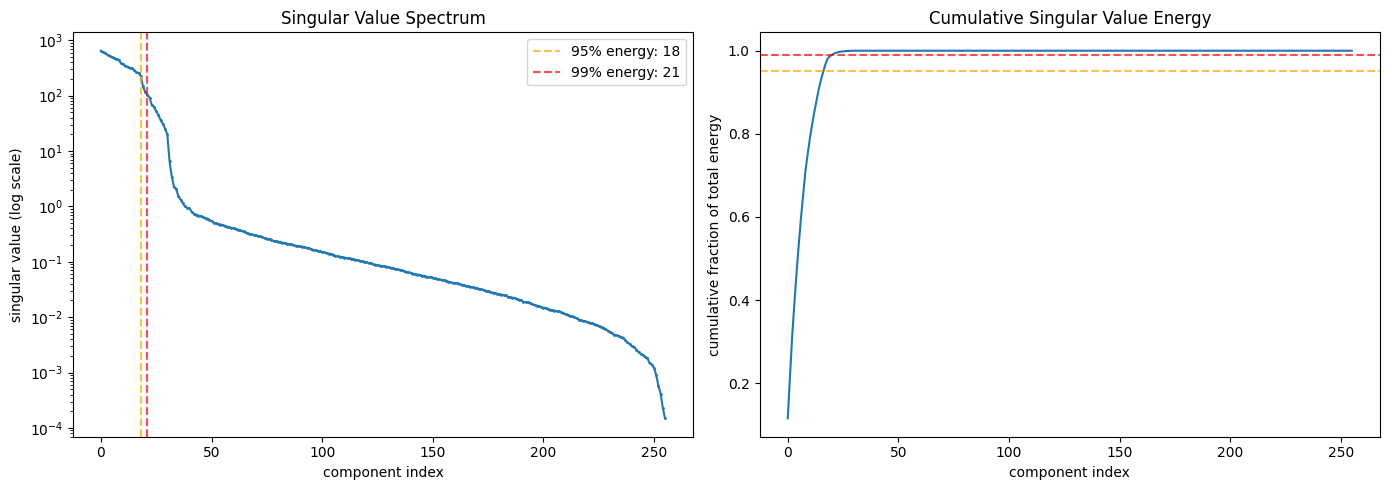

Embedding dimension: 256
Effective rank (entropy-based): 24.4 / 256
Numerical rank (95% energy): 18 / 256
Numerical rank (99% energy): 21 / 256
Top singular value ratio S[0]/S[1]: 1.07
Condition number S[0]/S[-1]: 4335480.0


In [19]:
# SVD analysis of the embedding matrix
# Use subsample for speed
svd_embeds = all_embeds - all_embeds.mean(axis=0, keepdims=True)  # center
_, S, _ = np.linalg.svd(svd_embeds[:20000], full_matrices=False)

# Normalized singular values -> effective rank
S_norm = S / S.sum()
eff_rank = float(np.exp(-np.sum(S_norm * np.log(S_norm + 1e-12))))
numerical_rank_99 = int(np.searchsorted(np.cumsum(S**2) / (S**2).sum(), 0.99)) + 1
numerical_rank_95 = int(np.searchsorted(np.cumsum(S**2) / (S**2).sum(), 0.95)) + 1

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].semilogy(S, marker=".", markersize=2)
axes[0].set_title("Singular Value Spectrum")
axes[0].set_xlabel("component index")
axes[0].set_ylabel("singular value (log scale)")
axes[0].axvline(numerical_rank_95, color="orange", linestyle="--", alpha=0.7, label=f"95% energy: {numerical_rank_95}")
axes[0].axvline(numerical_rank_99, color="red", linestyle="--", alpha=0.7, label=f"99% energy: {numerical_rank_99}")
axes[0].legend()

cumulative_energy = np.cumsum(S**2) / (S**2).sum()
axes[1].plot(cumulative_energy)
axes[1].axhline(0.95, linestyle="--", color="orange", alpha=0.7)
axes[1].axhline(0.99, linestyle="--", color="red", alpha=0.7)
axes[1].set_title("Cumulative Singular Value Energy")
axes[1].set_xlabel("component index")
axes[1].set_ylabel("cumulative fraction of total energy")

plt.tight_layout()
plt.show()

D = all_embeds.shape[1]
print(f"Embedding dimension: {D}")
print(f"Effective rank (entropy-based): {eff_rank:.1f} / {D}")
print(f"Numerical rank (95% energy): {numerical_rank_95} / {D}")
print(f"Numerical rank (99% energy): {numerical_rank_99} / {D}")
print(f"Top singular value ratio S[0]/S[1]: {S[0]/S[1]:.2f}")
print(f"Condition number S[0]/S[-1]: {S[0]/S[-1]:.1f}")

## 9. Interpretation Checklist

Compare these results against `tune_jepa_sigreg_global_16` to assess the ISAB-based backbone:

**Geometry (Sections 3-7):**
- Does PC1 correlate less with `n_valid_peaks`? (less sparsity-driven geometry)
- Is precursor m/z gradient structure maintained?
- Better or worse high-D connectivity?
- More or fewer UMAP disconnected components?

**Representation Quality (Section 8):**
- **Uniformity**: Is the cosine similarity distribution well-spread (mean near 0) or collapsed (mean near 1)?
- **Linear probes**: Are adduct/instrument balanced accuracies and precursor m/z R^2 competitive?
- **kNN purity**: Do nearest neighbors share labels at a rate significantly above random baseline?
- **Separability**: Is the inter/intra class distance ratio high? Are silhouette scores positive?
- **Effective rank**: Is the model using the full embedding dimension or collapsing to a low-rank subspace?